In [1]:
import pandas as pd
import matplotlib.pyplot as plt

info = pd.read_csv('meal_order_info.csv',encoding='utf-8')
info_befor = pd.read_csv('info_new.csv',encoding='utf-8')

info_all = pd.concat([info_befor,info])
print('查看各表的维数:\n',info.shape,info_befor.shape,info_all.shape)

查看各表的维数:
 (945, 21) (6611, 21) (7556, 21)


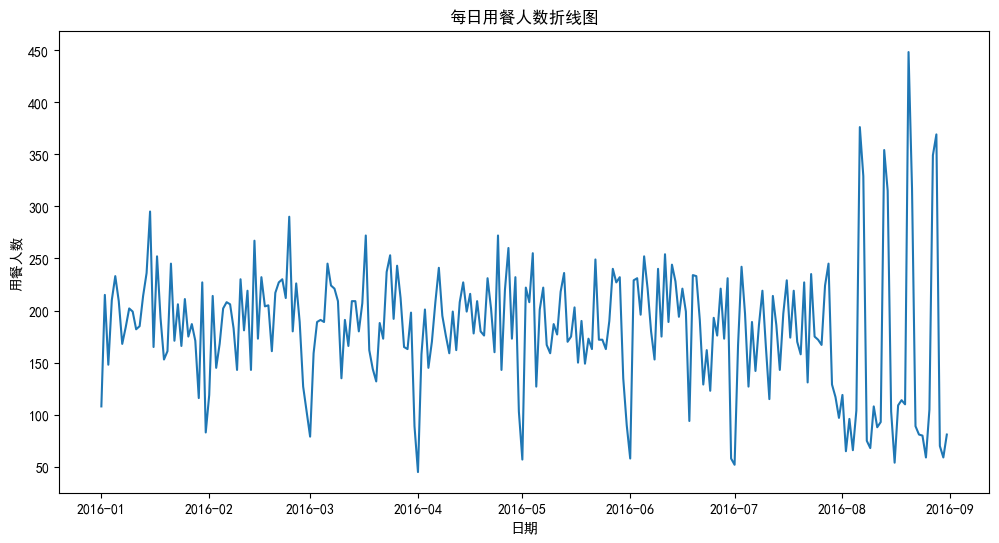

In [2]:
info = info_all[info_all['order_status'].isin([1])]
info = info.reset_index(drop=True)
for i,k in enumerate(info['use_start_time']):
    y = k.split()
    y = pd.to_datetime(y[0])
    info.loc[i,'use_start_time'] = y
groupbyday = info[['use_start_time','number_consumers','accounts_payable']].groupby(by = 'use_start_time')
sale_day = groupbyday.sum()
sale_day.columns = ['人数','销量']

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False
plt.figure(figsize=(12,6))
plt.title('每日用餐人数折线图')
plt.xlabel('日期')
plt.ylabel('用餐人数')
plt.plot(sale_day['人数'])
plt.show()

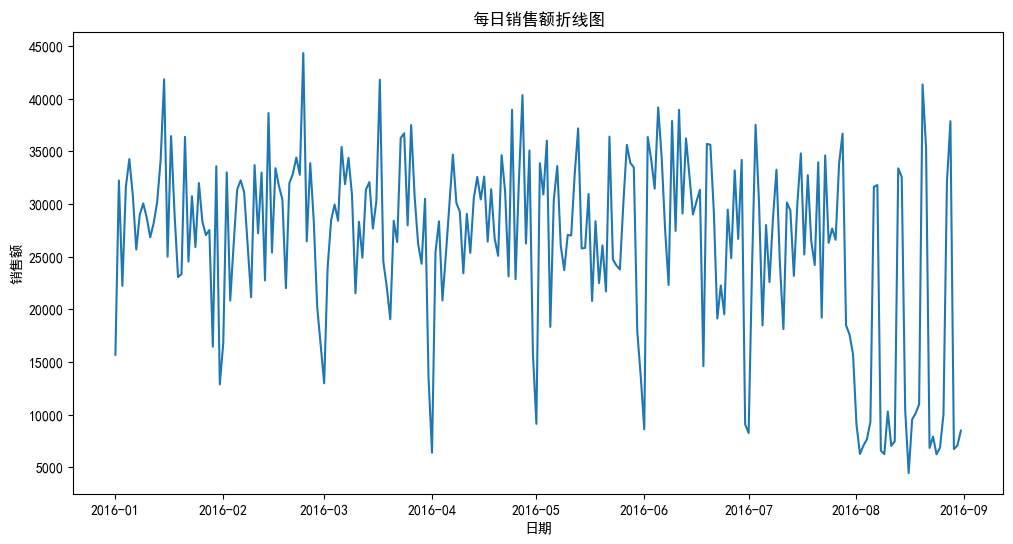

In [3]:
plt.figure(figsize=(12,6))
plt.title('每日销售额折线图')
plt.xlabel('日期')
plt.ylabel('销售额')
plt.plot(sale_day['销量'])
plt.show()

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
info_august = pd.read_csv('meal_order_info.csv',encoding='utf-8')
users_august = pd.read_csv('users.csv',encoding='gbk')

In [5]:
info_august_new = info_august[info_august['order_status'].isin([1])]
info_august_new = info_august_new.reset_index(drop=True)
print('提取的订单数据维数:',info_august_new.shape)

提取的订单数据维数: (933, 21)


In [6]:
info_august_new.to_csv("info_august_new.csv",index=False,encoding='utf-8')

In [7]:
for i in range (1,len(info_august_new)):
    num=users_august[users_august['USER_ID']==info_august_new.iloc[i-1,1]].index.tolist()
    users_august.iloc[num[0],14]=info_august_new.iloc[i-1,9]
    user=users_august

In [8]:
user['LAST_VISITS']=user['LAST_VISITS'].fillna(999)
user=user.drop(user[user['LAST_VISITS']==999].index.tolist())
user=user.iloc[:,[0,2,12,14]]
user.to_csv('users_august.csv',index=False,encoding='utf-8')
user.head()

,USER_ID,ACCOUNT,FIRST_VISIT,LAST_VISITS
2,982,叶亦凯,2014/8/18 21:41:57,2016/8/26 13:53:46
3,983,邓彬彬,2015/8/23 13:47:17,2016/8/21 17:16:00
4,984,张建涛,2014/12/24 19:26:30,2016/8/25 11:32:59
6,986,莫子建,2014/9/11 11:38:10,2016/8/20 11:15:06
7,987,易子歆,2015/2/24 21:25:34,2016/8/28 12:34:59


In [28]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
import numpy as np
info = pd.read_csv('info_august_new.csv',encoding='utf-8')
user = pd.read_csv('users_august.csv',encoding='utf-8')

In [29]:
user_value1 = pd.DataFrame(info['emp_id'].value_counts()).reset_index()
user_value1.columns = ['USER_ID','F']
print('F特征最大值:',max(user_value1['F']))
print('F特征最小值:',min(user_value1['F']))

F特征最大值: 10
F特征最小值: 1


In [30]:
user_value2 = info[['emp_id','expenditure']].groupby(by='emp_id').sum()
user_value2 = pd.DataFrame(user_value2).reset_index()
user_value2.columns = ['USER_ID','M']
user_value = pd.merge(user_value1,user_value2,on='USER_ID')
print('M特征最大值:',max(user_value['M']))
print('M特征最小值:',min(user_value['M']))

M特征最大值: 6037
M特征最小值: 80


In [31]:
user_value = pd.merge(user_value,user,on='USER_ID')
for i,k in enumerate(user_value['LAST_VISITS']):
    y = k.split()
    y = pd.to_datetime(y[0])
    user_value.loc[i,'LAST_VISITS'] = y

In [32]:
last_time = pd.to_datetime(user_value['LAST_VISITS'])
deadline = pd.to_datetime("2016-8-31")
user_value['R'] = deadline-last_time

In [33]:
print('R特征最大值:',max(user_value['R']))
print('R特征最小值:',min(user_value['R']))

R特征最大值: 30 days 00:00:00
R特征最小值: 0 days 00:00:00
